# Example: AI Sentiment Pipeline Deep Dive

In this example, we open the news pipeline that runs in production today. In parallel with the intraday engine's 30-minute fires, an hourly cron asks Claude with web search for recent headlines on each ticker, scores every headline in $[-1, +1]$ with a second Claude call, and persists the per-ticker aggregates to disk. At every engine fire, the runner reads the latest such file and consults one number per ticker, the news severity, before deciding whether to auto-execute a proposed trade or route it to evening human review. We trace the pipeline end to end on captured artifacts, document the on-disk dictionary the cron writes, and calibrate the threshold that controls auto-execute versus human review.

If the engine auto-executes most trades on most fires, when is human judgment worth interrupting? The course's deployed answer is that LLM-scored headline severity is the trigger: when a ticker is being talked about loudly, the engine punts that ticker's trade to the desk. The pipeline produces the loudness signal; a single threshold decides which trades route to a human. That threshold is the only news-related PM knob in production today.

> __Learning Objectives:__
>
> By the end of this example, we will be able to:
> * __Trace one captured headline through the pipeline:__ Open a real `news-*.jld2` artifact written by the hourly cron, pick one high-severity item, and walk its `text`, `claude_score`, and contribution to that ticker's [`sentiment`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#aggregate_news_factor) and `severity` aggregates. See exactly what the engine reads at the next fire.
> * __Document the artifact schema and the engine's join:__ Walk the on-disk dictionary keys (`source`, `fire_time`, `sentiment`, `severity`, `counts`, `corpus`) the cron persists, and show how the runner wraps per-ticker severity into the snapshot that [`gate_check`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#gate_check) consumes. Tie each field back to a line of `production_runner.jl`.
> * __Calibrate the severity threshold against the captured corpus:__ Sweep `news_severity_queue_threshold` over all captured fires and tickers, count the auto-execute and queue splits at each candidate value, and read the trade-off between human review burden and auto-execute risk. Compare with the deployed setting.

Let's open the box.

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

### Constants

In the code block below, we declare the bindings used throughout this example:

* `NEWS_DIR::String`: the directory where the hourly cron writes one `news-YYYY-MM-DD-HH.jld2` per fire.
* `PRODUCTION_S_MAX::Float64`: the production setting of `news_severity_queue_threshold` from `config/production-config.toml` (= 0.7).
* `S_MAX_GRID::Vector{Float64}`: candidate threshold values used in Task 3.
* `FOCUS_FIRE::String`: the captured-fire filename we trace in Task 1, picked for full ticker coverage.

In [2]:
# --- Step 1: Path to the on-disk artifacts ---
NEWS_DIR = _PATH_TO_NEWS;

# --- Step 2: Production threshold from config/production-config.toml ---
PRODUCTION_S_MAX = 0.7;

# --- Step 3: Candidate thresholds for the Task 3 sweep ---
S_MAX_GRID = collect(0.0:0.05:1.0);

# --- Step 4: The fire we trace in Task 1 ---
FOCUS_FIRE = "news-2026-05-08-18.jld2";

The hourly cron has captured a series of fires in `data/news/`. We load every `news-*.jld2` artifact (one per fire) plus the focus fire we trace in Task 1. In the code block below, we return: `fires::Vector{NamedTuple}` (one entry per captured fire with `path`, `fire_time`, `source`, `sentiment::Dict{String,Float64}`, `severity::Dict{String,Float64}`, `counts::Dict{String,Int}`, `corpus::`[`MyNewsCorpus`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#MyNewsCorpus)) and `focus::NamedTuple` (the same fields for the FOCUS_FIRE).

In [3]:
(; fires, focus) = let
    # --- Step 1: Enumerate captured fire artifacts (filter out budget-*.json and synthetic-corpus*) ---
    pattern = r"^news-\d{4}-\d{2}-\d{2}-\d{2}\.jld2$";
    files = filter(f -> occursin(pattern, f), readdir(NEWS_DIR));
    sort!(files);

    # --- Step 2: Load every fire into a typed NamedTuple ---
    fires = NamedTuple[];
    for f in files
        d = load_results(joinpath(NEWS_DIR, f));
        push!(fires, (
            path = joinpath(NEWS_DIR, f),
            fire_time = d["fire_time"],
            source = d["source"],
            sentiment = d["sentiment"],
            severity = d["severity"],
            counts = d["counts"],
            corpus = d["corpus"]));
    end

    # --- Step 3: Load the focus fire for Task 1 ---
    fpath = joinpath(NEWS_DIR, FOCUS_FIRE);
    fd = load_results(fpath);
    focus = (
        path = fpath,
        fire_time = fd["fire_time"],
        source = fd["source"],
        sentiment = fd["sentiment"],
        severity = fd["severity"],
        counts = fd["counts"],
        corpus = fd["corpus"]);

    println("Captured fires: ", length(fires), ", spanning ",
        minimum(fr.fire_time for fr in fires), " to ",
        maximum(fr.fire_time for fr in fires), ".")
    println("Focus fire:     ", FOCUS_FIRE,
        ", source = ", focus.source,
        ", tickers = ", length(focus.sentiment),
        ", items = ", length(focus.corpus.items), ".")
    (fires = fires, focus = focus)
end;

Captured fires: 22

, spanning 2026-05-04T07:36:22.196 to 2026-05-08T18:00:19.493.
Focus fire:     news-2026-05-08-18.jld2, source = anthropic_web, tickers = 22, items = 66.


___
## Task 1: Trace One Captured Headline

In this task, we follow a single news item from its on-disk record through to the per-ticker `sentiment` and `severity` numbers the engine reads at the next fire. Each item in the captured corpus is a [`MyNewsItem`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#MyNewsItem) carrying `ticker`, `text`, `claude_score`, and `source`; per-ticker aggregation then produces:

* `sentiment[ticker]` = mean of `claude_score` across items mentioning that ticker,
* `severity[ticker]` = max of `|claude_score|` across the same items,
* `counts[ticker]` = number of items.

Severity is loudness, not direction: a strongly bullish headline (+0.9) and a strongly bearish headline (-0.9) push severity up by the same amount.

> __What should we see?__
>
> The traced item is one of three headlines about the highest-severity ticker in the focus fire. Its `claude_score` is one of the three values aggregated into that ticker's `sentiment` (their mean), and its absolute value is one of three contenders for the ticker's `severity` (their max). When the item we trace happens to carry the largest absolute score, its `|claude_score|` equals `severity[ticker]` exactly.

The cell-bound result is `traced::NamedTuple` with the item, the contributing per-ticker score set, and the aggregated values; the cell also tabulates the first ten items in the focus corpus.

In [4]:
traced = let
    # --- Step 1: Pick the highest-severity ticker in the focus fire ---
    pairs = sort(collect(focus.severity); by = p -> -p[2]);
    ticker = first(pairs[1]);
    items_for_ticker = filter(it -> it.ticker == ticker, focus.corpus.items);
    isempty(items_for_ticker) && error("No items for ticker $(ticker) in focus fire.");

    # --- Step 2: Pick the item that drives severity (max |claude_score|) ---
    abs_scores = abs.([it.claude_score for it in items_for_ticker]);
    item = items_for_ticker[argmax(abs_scores)];

    # --- Step 3: Render the item's record ---
    println("Traced item:")
    println("  fire_time      = ", focus.fire_time)
    println("  ticker         = ", item.ticker)
    println("  source         = ", item.source)
    println("  claude_score   = ", round(item.claude_score, digits = 3))
    println("  text           = ", item.text)

    # --- Step 4: Show how this item contributes to per-ticker aggregates ---
    println()
    println("All items for ", ticker, " in this fire:")
    for (i, it) in enumerate(items_for_ticker)
        marker = it === item ? "  <- traced item" : "";
        println("  [", i, "]  claude_score = ", round(it.claude_score, digits = 3), marker)
    end
    println()
    println("Aggregated per-ticker values for ", ticker, ":")
    println("  sentiment[", ticker, "]  = mean(claude_score)   = ", round(focus.sentiment[ticker], digits = 3))
    println("  severity[",  ticker, "]   = max(|claude_score|)  = ", round(focus.severity[ticker], digits = 3))
    println("  counts[",    ticker, "]     = ", focus.counts[ticker])

    # --- Step 5: First ten items in the focus corpus ---
    rows = NamedTuple[];
    for it in focus.corpus.items[1:min(10, length(focus.corpus.items))]
        push!(rows, (Ticker = it.ticker,
            Claude_score = round(it.claude_score, digits = 3),
            Abs_score = round(abs(it.claude_score), digits = 3),
            Text = it.text[1:min(60, length(it.text))]));
    end
    println()
    println("First 10 items in the focus fire:")
    pretty_table(DataFrame(rows); backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    (item = item, ticker = ticker, all_scores = [it.claude_score for it in items_for_ticker],
        sentiment = focus.sentiment[ticker], severity = focus.severity[ticker])
end;

Traced item:


  fire_time      = 2026-05-08T18:00:19.493
  ticker         = JPM
  source         = anthropic_web
  claude_score   = 0.9
  text           = Banking Giants JPMorgan and Mastercard Link with Ripple to Execute Historic U.S. Treasury Settlement via XRP Ledger

All items for JPM in this fire:
  [1]  claude_score = 0.2
  [2]  claude_score = 0.9  <- traced item
  [3]  claude_score = -0.4

Aggregated per-ticker values for JPM:
  sentiment[JPM]  = mean(claude_score)   = 0.233
  severity[JPM]   = max(|claude_score|)  = 0.9
  counts[JPM

]     = 3

First 10 items in the focus fire:
 -------- -------------- ----------- --------------------------------------------------------------
  Ticker   Claude_score   Abs_score                                                           Text 
  String        Float64     Float64                                                         String 
 -------- -------------- ----------- --------------------------------------------------------------
     DIS            0.1         0.1      Disney Q2 FY26 Earnings: Commentary from CEO Josh D'Amaro
     DIS            0.7         0.7   Josh D'Amaro Has a 'Vision' for Disney. That Makes DIS Stock
     DIS            0.6         0.6   Disney Stock Is Up 8% Today: Is It Outperforming Other Strea
    NFLX           -0.3         0.3   Top Netflix Executives Make Major Move With Their Stock Hold
    NFLX           -0.6         0.6   Warner Bros. Discovery Net Loss Includes $2.8B Termination F
    NFLX            0.3         0.3   Netflix's First Half I

___
## Task 2: Document the Schema and the Engine's Join

In this task, we walk the keys of the on-disk artifact written by `news_scorer.jl` and trace exactly how the runner consumes it at the next fire. Each `news-*.jld2` is a `Dict{String,Any}` with six keys; the engine reads two of them into per-ticker dicts and then wraps each ticker's severity into a per-ticker `(news_severity = ...,)` NamedTuple that [`gate_check`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#gate_check) takes as one of its inputs.

The relevant lines of the production runner:

* `production_runner.jl:191-219` defines `latest_news_artifact(fire_time, tickers)`, which scans `NEWS_DIR` for the most recent `news-*.jld2` whose stamp is at or before `fire_time` and returns its `sentiment` and `severity` dicts (defaulted to zero per ticker if the file is missing).
* `production_runner.jl:458-460` builds the per-ticker snapshot the gate consumes:
    * `snaps[t] = (news_severity = news.severity[t],)` for each ticker `t`.
* `production_runner.jl:475-476` calls `split_intraday_trades(proposed_trades, snaps, gate_config, ...)`; inside that, `gate_check` checks `news_severity > news_severity_queue_threshold` and, if true, routes the trade to the queue.
* `production_runner.jl:608` reads `news.severity` again at the close to flag tickers above `flag_severity_threshold` on tomorrow's ticket.

> __What should we see?__
>
> The on-disk dict has six top-level keys. The engine uses two: `sentiment` (recorded into the engine snapshot for the audit log) and `severity` (used as the gate input). The corpus, item texts, source, and counts are kept on disk for post-hoc analysis but do not enter the live decision path. This is the entire surface area of news in production today.

The cell-bound result is `schema::DataFrame` documenting each key plus a per-ticker view of the top-five severities in the focus fire and which would route to the queue under the production threshold.

In [5]:
schema = let
    # --- Step 1: Document the on-disk artifact keys ---
    rows = [
        (Key = "fire_time", Type = "DateTime",
            Role = "Stamps the audit log; engine uses Date(fire_time) for tape rotation."),
        (Key = "source", Type = "String",
            Role = "Pipeline mode: synthetic, newsapi, or anthropic_web."),
        (Key = "sentiment", Type = "Dict{String,Float64}",
            Role = "Per-ticker mean of claude_score; recorded in engine_snapshot for audit."),
        (Key = "severity", Type = "Dict{String,Float64}",
            Role = "Per-ticker max of |claude_score|; THE gate input in production."),
        (Key = "counts", Type = "Dict{String,Int}",
            Role = "Per-ticker n_items; kept for post-hoc analysis, not read by the engine."),
        (Key = "corpus", Type = "MyNewsCorpus",
            Role = "Item-level records (text, claude_score, source); kept for analysis only."),
    ];
    println("Schema of news-*.jld2 (written by news_scorer.jl, read by latest_news_artifact):")
    pretty_table(DataFrame(rows); backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    # --- Step 2: Build the per-ticker gate snapshot the way production_runner.jl does ---
    tickers = sort(collect(keys(focus.severity)));
    snaps = Dict{String,NamedTuple}(t => (news_severity = focus.severity[t],) for t in tickers);

    # --- Step 3: Show top-5 severities in the focus fire and queue routing under the production threshold ---
    println()
    println("Per-ticker snapshot the runner builds at production_runner.jl:459:")
    println("  snaps[t] = (news_severity = focus.severity[t],)")
    println()
    println("Top-5 tickers by severity in this fire (production s_max = ", PRODUCTION_S_MAX, "):")
    by_sev = sort(collect(focus.severity); by = p -> -p[2]);
    sev_rows = NamedTuple[];
    for (t, sev) in by_sev[1:5]
        push!(sev_rows, (
            Ticker = t,
            Severity = round(sev, digits = 3),
            Sentiment = round(focus.sentiment[t], digits = 3),
            Counts = focus.counts[t],
            Routes_to_queue = sev > PRODUCTION_S_MAX ? "yes" : "no",
        ));
    end
    pretty_table(DataFrame(sev_rows); backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    DataFrame(rows)
end;

Schema of news-*.jld2 (written by news_scorer.jl, read by latest_news_artifact):
 ----------- ---------------------- --------------------------------------------------------------------------
        Key                   Type                                                                       Role 
     String                 String                                                                     String 
 ----------- ---------------------- --------------------------------------------------------------------------
  fire_time               DateTime       Stamps the audit log; engine uses Date(fire_time) for tape rotation.
     source                 String                       Pipeline mode: synthetic, newsapi, or anthropic_web.
  sentiment   Dict{String,Float64}    Per-ticker mean of claude_score; recorded in engine_snapshot for audit.
   severity   Dict{String,Float64}            Per-ticker max of |claude_score|; THE gate input in production.
     counts       Dict{String,Int} 

Per-ticker snapshot the runner builds at production_runner.jl:459:
  snaps[t] = (news_severity = focus.severity[t],)

Top-5 tickers by severity in this fire (production s_max = 0.7):
 -------- ---------- ----------- -------- -----------------
  Ticker   Severity   Sentiment   Counts   Routes_to_queue 
  String    Float64     Float64    Int64            String 
 -------- ---------- ----------- -------- -----------------
     JPM        0.9       0.233        3               yes
    MSFT        0.9       0.433        3               yes
     LLY        0.9         0.8        3               yes
    AAPL        0.9       0.433        3               yes
     AMT       0.85       0.417        3               yes
 -------- ---------- ----------- -------- -----------------


___
## Task 3: Calibrate the Severity Threshold Against the Captured Corpus

In this task, we calibrate the production knob `news_severity_queue_threshold` against the corpus the cron has accumulated. At every fire and every ticker, this threshold is what decides whether a hypothetical proposed trade in that ticker auto-executes or routes to the evening human queue. A lower threshold means more trades go to the desk (safer, more queue burden); a higher threshold means fewer trades queue (faster auto-execution, more model trust). The trade-off has no a-priori right answer; the calibration table makes the operating-point choice explicit.

> __What should we see?__
>
> Sweeping the threshold from 0 to 1 across all captured ticker-fires:
>
> * At $s_{\max} = 0$, every ticker-fire with any non-zero severity routes to the queue: this is the worst case for auto-execute throughput.
> * At $s_{\max} = 1$, no ticker-fire ever queues on news: the gate is effectively off.
> * The current production setting of $0.7$ lands at a specific operating point on the curve; the calibration tells us what fraction of trades a senior PM is committing to review at that setting.

The cell-bound result is `sweep_table::DataFrame` (one row per candidate threshold, with auto and queue counts and percentages), plus a [`Plots`](https://docs.juliaplots.org/stable/) figure of the calibration curve.

Calibrating against 22 fires across 450 ticker-fires (avg 20.5 tickers/fire).

Threshold sweep:


 --------- ------- -------- ---------- ------------ ------------
    S_max    Auto   Queued   Auto_pct   Queued_pct   Production 
  Float64   Int64    Int64    Float64      Float64       String 
 --------- ------- -------- ---------- ------------ ------------
      0.0      16      434        3.6         96.4
     0.05      16      434        3.6         96.4
      0.1      34      416        7.6         92.4
     0.15      34      416        7.6         92.4
      0.2      44      406        9.8         90.2
     0.25      44      406        9.8         90.2
      0.3      73      377       16.2         83.8
     0.35      73      377       16.2         83.8
      0.4      86      364       19.1         80.9
     0.45      86      364       19.1         80.9
      0.5      91      359       20.2         79.8
     0.55      91      359       20.2         79.8
      0.6     177      273       39.3         60.7
     0.65     178      272       39.6         60.4
      0.7     278      17

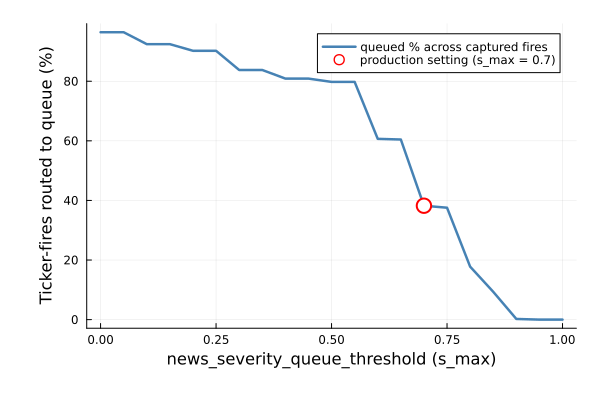

In [6]:
sweep_table = let
    # --- Step 1: Flatten all (fire, ticker) severity readings into a single vector ---
    all_severities = Float64[];
    for fr in fires
        for (_, sev) in fr.severity
            push!(all_severities, sev);
        end
    end
    n_total = length(all_severities);
    println("Calibrating against ", length(fires), " fires across ", n_total,
        " ticker-fires (avg ", round(n_total / length(fires), digits = 1), " tickers/fire).")

    # --- Step 2: Sweep s_max over the candidate grid ---
    rows = NamedTuple[];
    for s in S_MAX_GRID
        n_queue = count(>(s), all_severities);
        n_auto  = n_total - n_queue;
        push!(rows, (
            S_max = round(s, digits = 2),
            Auto = n_auto,
            Queued = n_queue,
            Auto_pct = round(100 * n_auto / n_total, digits = 1),
            Queued_pct = round(100 * n_queue / n_total, digits = 1),
            Production = isapprox(s, PRODUCTION_S_MAX) ? "<-" : "",
        ));
    end
    df = DataFrame(rows);
    println()
    println("Threshold sweep:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));

    # --- Panel 1: Calibration curve ---
    queued_frac = [count(>(s), all_severities) / n_total for s in S_MAX_GRID];
    p = plot(S_MAX_GRID, 100 .* queued_frac;
        xlabel = "news_severity_queue_threshold (s_max)",
        ylabel = "Ticker-fires routed to queue (%)",
        label = "queued % across captured fires",
        lw = 2.5, color = :steelblue, legend = :topright,
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 4Plots.mm, top_margin = 4Plots.mm);
    prod_idx = findfirst(s -> isapprox(s, PRODUCTION_S_MAX), S_MAX_GRID);
    if prod_idx !== nothing
        scatter!(p, [S_MAX_GRID[prod_idx]], [100 * queued_frac[prod_idx]];
            markershape = :circle, markersize = 8,
            markercolor = :white, markerstrokecolor = :red, markerstrokewidth = 2.5,
            label = "production setting (s_max = $(PRODUCTION_S_MAX))");
    end
    display(p);

    df
end;

___
## Summary

In this example, we opened the news-driven part of the production engine. The hourly cron `news_scorer.jl --mode=anthropic_web` calls Claude with web search per ticker, scores each headline in $[-1, +1]$ via a second Claude call, and writes per-ticker `sentiment`, `severity`, and `counts` to `data/news/news-YYYY-MM-DD-HH.jld2`. The intraday engine reads the latest such file at every fire via `latest_news_artifact`, takes per-ticker severity, and routes loud-news trades to the evening queue.

> __Key Takeaways:__
>
> * __Per-ticker news scoring is real and runs hourly:__ Each fire produces one severity, one sentiment, and one count per ticker, written to JLD2 and read by the next engine fire. Severity is loudness, not direction; a bullish and a bearish headline of equal strength contribute identically to the gate decision.
> * __Severity is the engine's news input:__ The runner reads `severity[ticker]` from the latest `news-*.jld2` and passes it through [`gate_check`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#gate_check); severity above the threshold routes the trade to evening review, leaving the SIM and the EMA-crossover $\lambda_t$ to decide capital allocation.
> * __The threshold is the single PM knob:__ Sweeping it across the captured corpus traces a calibration curve from _everything reviews_ at small $s_{\max}$ to _nothing reviews_ at large $s_{\max}$. The production setting of $0.7$ commits the desk to a specific review burden the calibration table makes explicit.

### Disclaimer

This content is for educational purposes only and does not constitute investment advice. The captured news corpus is a small sample drawn from a paper-trading deployment; production use of LLM-scored news flow demands additional validation, monitoring, and operational controls.

___